<a href="https://colab.research.google.com/github/lunamonnlight/PF_169493/blob/main/lab06A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/pjastr-uwm/fakultet_io_2026/blob/main/lab06/lab06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Eksploracyjna analiza danych (EDA) na zbiorze z benchmarku KLEJ

W tym notatniku przećwiczymy:

1. Ładowanie datasetu z benchmarku KLEJ za pomocą biblioteki `datasets` (Hugging Face)
2. Podstawową inspekcję struktury danych
3. Analizę rozkładu klas (etykiet sentymentu)
4. Analizę statystyk tekstowych (długość recenzji, liczba słów)
5. Wizualizację wyników za pomocą `matplotlib` i `seaborn`
6. Wstępną analizę zawartości tekstowej (najczęstsze słowa)

---
## 0. Instalacja i import bibliotek

Google Colab wymaga doinstalowania biblioteki `datasets` z Hugging Face. Pozostałe pakiety (`matplotlib`, `seaborn`, `pandas`, `numpy`) są już dostępne w środowisku Colab.

In [1]:
!pip install datasets -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from datasets import load_dataset

sns.set_theme(style="whitegrid")
print("Wszystko gotowe!")

Wszystko gotowe!


---
## 1. Przykład z omówieniem -- ładowanie datasetu KLEJ PolEmo2.0

### Czym jest KLEJ?

**KLEJ** (Kompleksowa Lista Ewaluacji Językowych) to benchmark do ewaluacji modeli rozumienia języka polskiego. Składa się z dziewięciu zadań obejmujących różne domeny i aspekty NLP.

### Dataset PolEmo2.0 (In-Domain)

**PolEmo2.0** to zbiór recenzji konsumenckich z czterech domen: medycyna, hotele, produkty i uczelnie. Każda recenzja jest oznaczona etykietą sentymentu:
- `__label__meta_plus_m` -- pozytywny
- `__label__meta_minus_m` -- negatywny
- `__label__meta_zero` -- neutralny
- `__label__meta_amb` -- ambiwalentny

Wariant **In-Domain** testuje model na danych z tych samych domen, na których był trenowany (medycyna i hotele).

In [3]:
dataset = load_dataset("allegro/klej-polemo2-in")

print(type(dataset))
print(dataset)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

valid.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/5783 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/723 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/722 [00:00<?, ? examples/s]

<class 'datasets.dataset_dict.DatasetDict'>
DatasetDict({
    train: Dataset({
        features: ['sentence', 'target'],
        num_rows: 5783
    })
    validation: Dataset({
        features: ['sentence', 'target'],
        num_rows: 723
    })
    test: Dataset({
        features: ['sentence', 'target'],
        num_rows: 722
    })
})


In [4]:
# Podgląd pierwszego przykładu ze zbioru treningowego
print(dataset["train"][0])

{'sentence': 'Super lekarz i człowiek przez duże C . Bardzo duże doświadczenie i trafne diagnozy . Wielka cierpliwość do ludzi starszych . Od lat opiekuje się moją Mamą staruszką , i twierdzę , że mamy duże szczęście , że mamy takiego lekarza . Naprawdę nie wiem cobyśmy zrobili , gdyby nie Pan doktor . Dzięki temu , moja mama żyje . Każda wizyta u specjalisty jest u niego konsultowana i uważam , że jest lepszy od każdego z nich . Mamy do Niego prawie nieograniczone zaufanie . Można wiele dobrego o Panu doktorze jeszcze napisać . Niestety , ma bardzo dużo pacjentów , jest przepracowany ( z tego powodu nawet obawiam się o jego zdrowie ) i dostęp do niego jest trudny , ale zawsze możliwy .', 'target': '__label__meta_plus_m'}


### Interpretacja

Obiekt `dataset` to `DatasetDict` zawierający splity: `train`, `validation` i `test`. Każdy przykład ma dwa pola:
- `sentence` -- tekst recenzji
- `target` -- etykieta sentymentu (string)

Biblioteka `datasets` automatycznie pobiera dane z Hugging Face Hub i cachuje je lokalnie.

### 1.1 Konwersja do pandas DataFrame

Do eksploracyjnej analizy danych wygodniej pracować z DataFrame z biblioteki pandas.

In [5]:
df_train = dataset["train"].to_pandas()
df_val = dataset["validation"].to_pandas()
df_test = dataset["test"].to_pandas()

print(f"Zbiór treningowy:   {df_train.shape[0]} przykładów")
print(f"Zbiór walidacyjny:  {df_val.shape[0]} przykładów")
print(f"Zbiór testowy:      {df_test.shape[0]} przykładów")
print(f"\nŁącznie: {df_train.shape[0] + df_val.shape[0] + df_test.shape[0]} przykładów")

Zbiór treningowy:   5783 przykładów
Zbiór walidacyjny:  723 przykładów
Zbiór testowy:      722 przykładów

Łącznie: 7228 przykładów


In [6]:
df_train.head(10)

,sentence,target
0,Super lekarz i człowiek przez duże C . Bardzo ...,__label__meta_plus_m
1,Bardzo olewcze podejscie do pacjenta . Przypro...,__label__meta_minus_m
2,Lekarz zalecił mi kurację alternatywną do doty...,__label__meta_amb
3,""" Konsumenci oczywiście kierują się ceną . Te ...",__label__meta_zero
4,Pani Doktor Iwona jest profesjonalistką w każd...,__label__meta_plus_m
5,Jest nie prawda co napisal ten internauta . Te...,__label__meta_plus_m
6,Krzysztof jest ZNAKOMITYM fizjoterapeutą ! Prz...,__label__meta_plus_m
7,"Pani Doktor bardzo delikatna , wygląda na bard...",__label__meta_amb
8,jest bardzo dobrym lekarzem miłu ciepły troszc...,__label__meta_plus_m
9,"Lekarz ten przyjął mnie nie uprzedzając , że n...",__label__meta_minus_m


In [7]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5783 entries, 0 to 5782
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   sentence  5783 non-null   object
 1   target    5783 non-null   object
dtypes: object(2)
memory usage: 90.5+ KB


### Interpretacja

DataFrame ma dwie kolumny typu `object` (string). Nie ma brakujących wartości (`Non-Null Count` = liczba wierszy). Zbiór treningowy jest największy, co jest typowe dla podziału train/val/test.

### 1.2 Rozkład klas (etykiet sentymentu)

Sprawdzamy, ile przykładów przypada na każdą klasę -- czy dane są zbalansowane?

In [8]:
# Mapowanie etykiet na czytelne nazwy
label_map = {
    "__label__meta_plus_m": "pozytywny",
    "__label__meta_minus_m": "negatywny",
    "__label__meta_zero": "neutralny",
    "__label__meta_amb": "ambiwalentny"
}

df_train["label"] = df_train["target"].map(label_map)

print("Rozkład klas w zbiorze treningowym:")
print(df_train["label"].value_counts())
print(f"\nProporcje:")
print(df_train["label"].value_counts(normalize=True).round(3))

Rozkład klas w zbiorze treningowym:
label
negatywny       2194
pozytywny       1568
ambiwalentny    1050
neutralny        971
Name: count, dtype: int64

Proporcje:
label
negatywny       0.379
pozytywny       0.271
ambiwalentny    0.182
neutralny       0.168
Name: proportion, dtype: float64


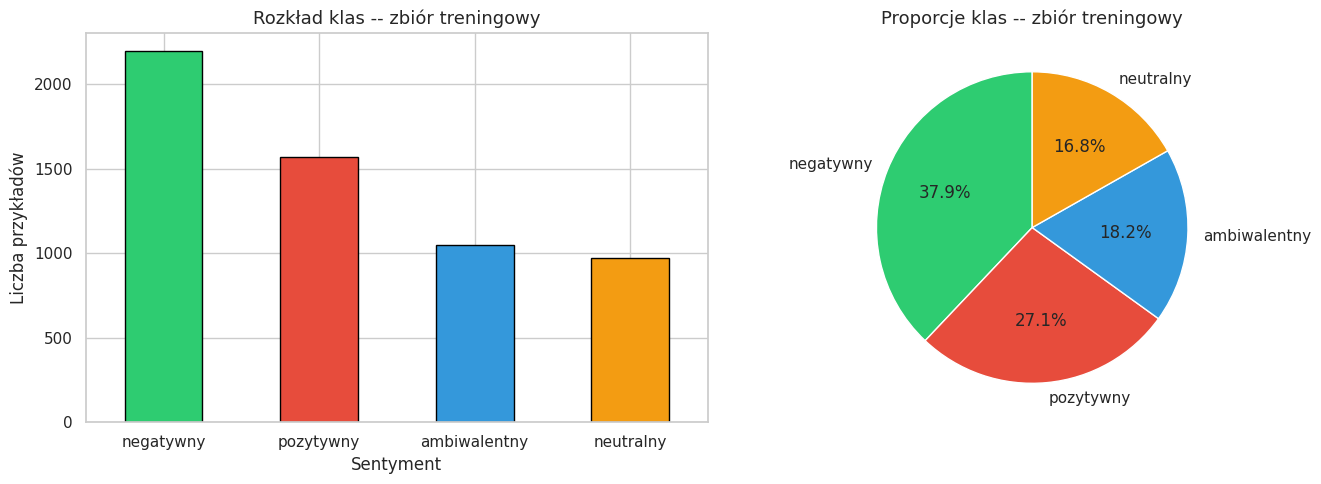

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Wykres słupkowy
colors = ["#2ecc71", "#e74c3c", "#3498db", "#f39c12"]
df_train["label"].value_counts().plot(kind="bar", ax=axes[0], color=colors, edgecolor="black")
axes[0].set_title("Rozkład klas -- zbiór treningowy", fontsize=13)
axes[0].set_xlabel("Sentyment")
axes[0].set_ylabel("Liczba przykładów")
axes[0].tick_params(axis="x", rotation=0)

# Wykres kołowy
df_train["label"].value_counts().plot(
    kind="pie", ax=axes[1], autopct="%1.1f%%", colors=colors, startangle=90
)
axes[1].set_ylabel("")
axes[1].set_title("Proporcje klas -- zbiór treningowy", fontsize=13)

plt.tight_layout()
plt.show()

### Interpretacja

Rozkład klas pokazuje, czy dataset jest **zbalansowany** (równe proporcje) czy **niezbalansowany**. Nierównomierne proporcje mogą wpływać na jakość trenowania modeli -- klasy mniejszościowe mogą być gorzej rozpoznawane. W takich przypadkach stosuje się techniki takie jak oversampling, class weights lub metrykę F1 zamiast accuracy.

### 1.3 Analiza długości tekstów

Sprawdzamy rozkład długości recenzji (w znakach i w słowach) -- to ważna informacja przy wyborze maksymalnej długości sekwencji dla tokenizera.

In [10]:
df_train["num_chars"] = df_train["sentence"].str.len()
df_train["num_words"] = df_train["sentence"].str.split().str.len()

print("Statystyki długości (znaki):")
print(df_train["num_chars"].describe().round(1))
print(f"\nStatystyki długości (słowa):")
print(df_train["num_words"].describe().round(1))

Statystyki długości (znaki):
count    5783.0
mean      780.6
std       433.1
min         1.0
25%       483.0
50%       698.0
75%       942.0
max      5391.0
Name: num_chars, dtype: float64

Statystyki długości (słowa):
count    5783.0
mean      137.1
std        77.5
min         1.0
25%        85.0
50%       121.0
75%       161.5
max       987.0
Name: num_words, dtype: float64


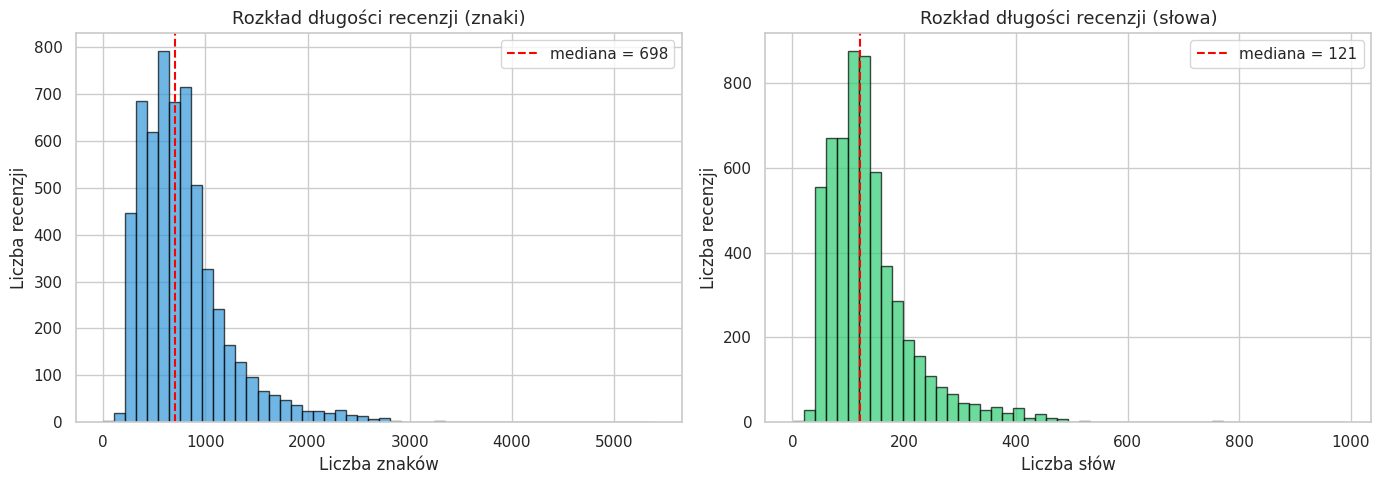

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_train["num_chars"], bins=50, color="#3498db", edgecolor="black", alpha=0.7)
axes[0].axvline(df_train["num_chars"].median(), color="red", linestyle="--", label=f'mediana = {df_train["num_chars"].median():.0f}')
axes[0].set_title("Rozkład długości recenzji (znaki)", fontsize=13)
axes[0].set_xlabel("Liczba znaków")
axes[0].set_ylabel("Liczba recenzji")
axes[0].legend()

axes[1].hist(df_train["num_words"], bins=50, color="#2ecc71", edgecolor="black", alpha=0.7)
axes[1].axvline(df_train["num_words"].median(), color="red", linestyle="--", label=f'mediana = {df_train["num_words"].median():.0f}')
axes[1].set_title("Rozkład długości recenzji (słowa)", fontsize=13)
axes[1].set_xlabel("Liczba słów")
axes[1].set_ylabel("Liczba recenzji")
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretacja

Histogramy pokazują, że rozkład długości recenzji jest **prawoskośny** -- większość tekstów jest relatywnie krótka, ale zdarzają się bardzo długie recenzje. Mediana (czerwona linia przerywana) jest bardziej odporna na wartości odstające niż średnia i lepiej oddaje "typową" długość tekstu.

### 1.4 Długość tekstu a sentyment

Czy istnieje związek między długością recenzji a jej sentymentem?

/tmp/ipykernel_5430/3500886533.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_train, x="label", y="num_words", ax=ax, palette=colors,


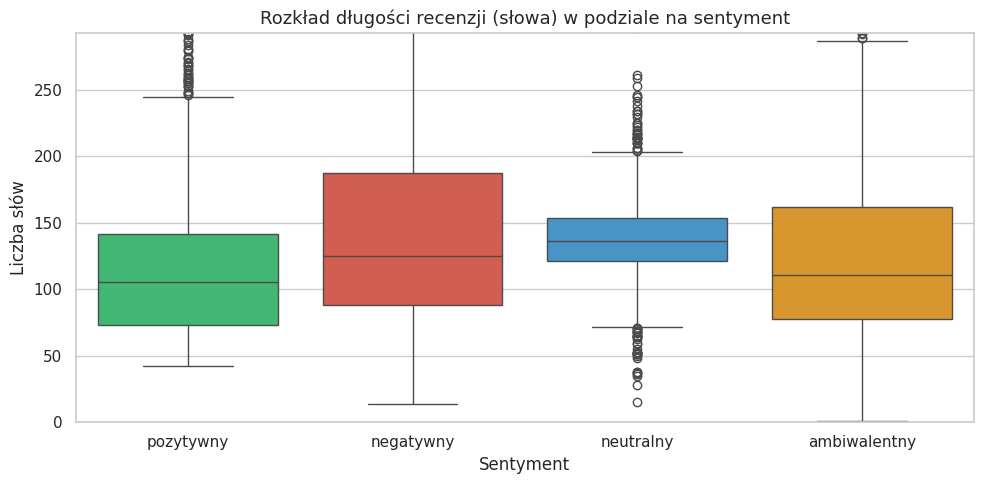

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))

sns.boxplot(data=df_train, x="label", y="num_words", ax=ax, palette=colors,
            order=["pozytywny", "negatywny", "neutralny", "ambiwalentny"])
ax.set_title("Rozkład długości recenzji (słowa) w podziale na sentyment", fontsize=13)
ax.set_xlabel("Sentyment")
ax.set_ylabel("Liczba słów")
ax.set_ylim(0, df_train["num_words"].quantile(0.95))  # obcięcie ekstremalnych wartości

plt.tight_layout()
plt.show()

### Interpretacja

Boxplot pozwala porównać rozkłady długości tekstu między klasami. Mediana (linia wewnątrz pudełka), rozstęp międzykwartylowy (wysokość pudełka) i wartości odstające (kropki) dają obraz tego, czy niektóre kategorie sentymentu wiążą się z dłuższymi lub krótszymi recenzjami.

### 1.5 Najczęstsze słowa

Prosta analiza frekwencji słów pozwala zobaczyć, jakie tematy dominują w zbiorze danych.

In [13]:
import re

def tokenize_simple(text):
    """Prosta tokenizacja: lowercase + usunięcie znaków specjalnych."""
    text = text.lower()
    tokens = re.findall(r'\b[a-ząćęłńóśźż]+\b', text)
    return tokens

# Stopwords -- podstawowa lista polskich stopwordów
polish_stopwords = {
    "i", "w", "na", "z", "do", "nie", "się", "to", "jest", "że",
    "o", "jak", "ale", "co", "tak", "za", "po", "od", "już", "a",
    "przez", "by", "tym", "ze", "tego", "ten", "ta", "te", "bardzo",
    "też", "tylko", "czy", "był", "była", "było", "być", "są",
    "ma", "ich", "dla", "mnie", "mi", "ja", "sobie", "go", "pan",
    "przy", "u", "no", "jeszcze", "tu", "tam", "kiedy", "gdy",
    "wszystko", "może", "więc", "który", "która", "które", "których",
    "którzy", "mam", "będzie", "moim", "mojej", "mój", "moja",
    "bo", "ni", "lub"
}

all_words = []
for text in df_train["sentence"]:
    tokens = tokenize_simple(text)
    filtered = [t for t in tokens if t not in polish_stopwords and len(t) > 2]
    all_words.extend(filtered)

word_freq = Counter(all_words)
top_20 = word_freq.most_common(20)

print("20 najczęstszych słów (po usunięciu stopwordów):")
for word, count in top_20:
    print(f"  {word:20s} {count}")

20 najczęstszych słów (po usunięciu stopwordów):
  śmy                  2659
  hotelu               2652
  hotel                2538
  pani                 2236
  doktor               1816
  polecam              1638
  można                1336
  sie                  1327
  pokoju               1301
  obsługa              1237
  pokoje               1194
  niestety             1118
  bez                  1114
  pokój                1063
  nawet                1020
  brak                 1012
  oraz                 1003
  jednak               974
  jedzenie             864
  lekarza              821


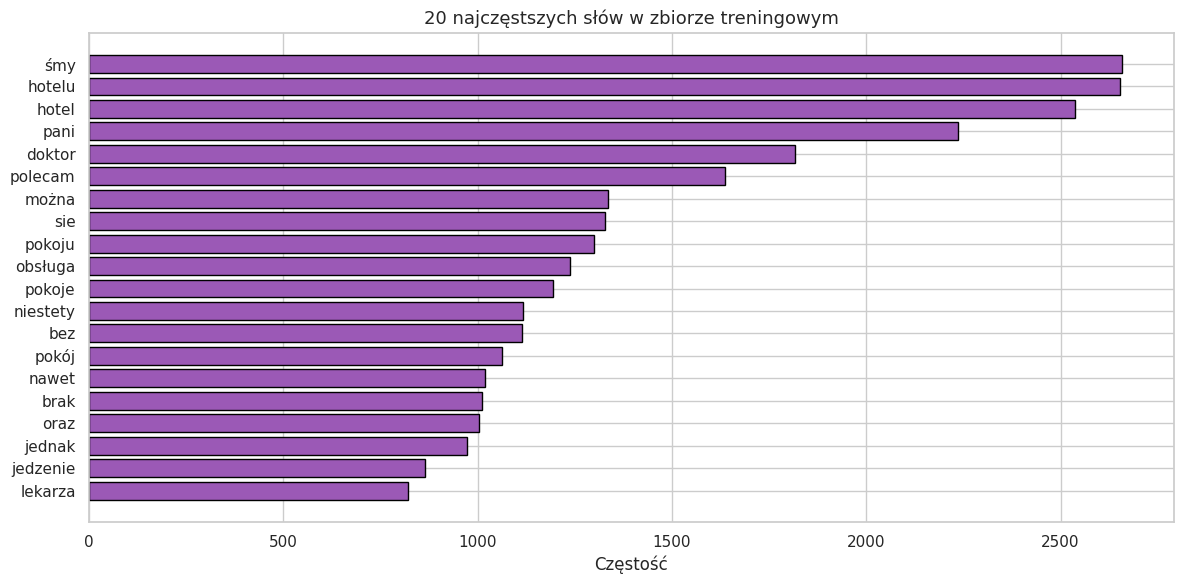

In [14]:
words, counts = zip(*top_20)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(words)), counts, color="#9b59b6", edgecolor="black")
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words)
ax.invert_yaxis()
ax.set_xlabel("Częstość")
ax.set_title("20 najczęstszych słów w zbiorze treningowym", fontsize=13)

plt.tight_layout()
plt.show()

### Interpretacja

Lista najczęstszych słów odzwierciedla domeny datasetu (medycyna i hotele). Słowa takie jak "lekarz", "hotel", "pokój" wskazują na tematykę recenzji. Warto zauważyć, że prosta tokenizacja i lista stopwordów nie są idealne -- w pełni profesjonalnej analizie użylibyśmy lematyzatora (np. z biblioteki `spaCy` z modelem `pl_core_news_md`).

### 1.6 Najczęstsze słowa w podziale na sentyment

Sprawdźmy, czy charakterystyczne słowa różnią się w zależności od sentymentu.

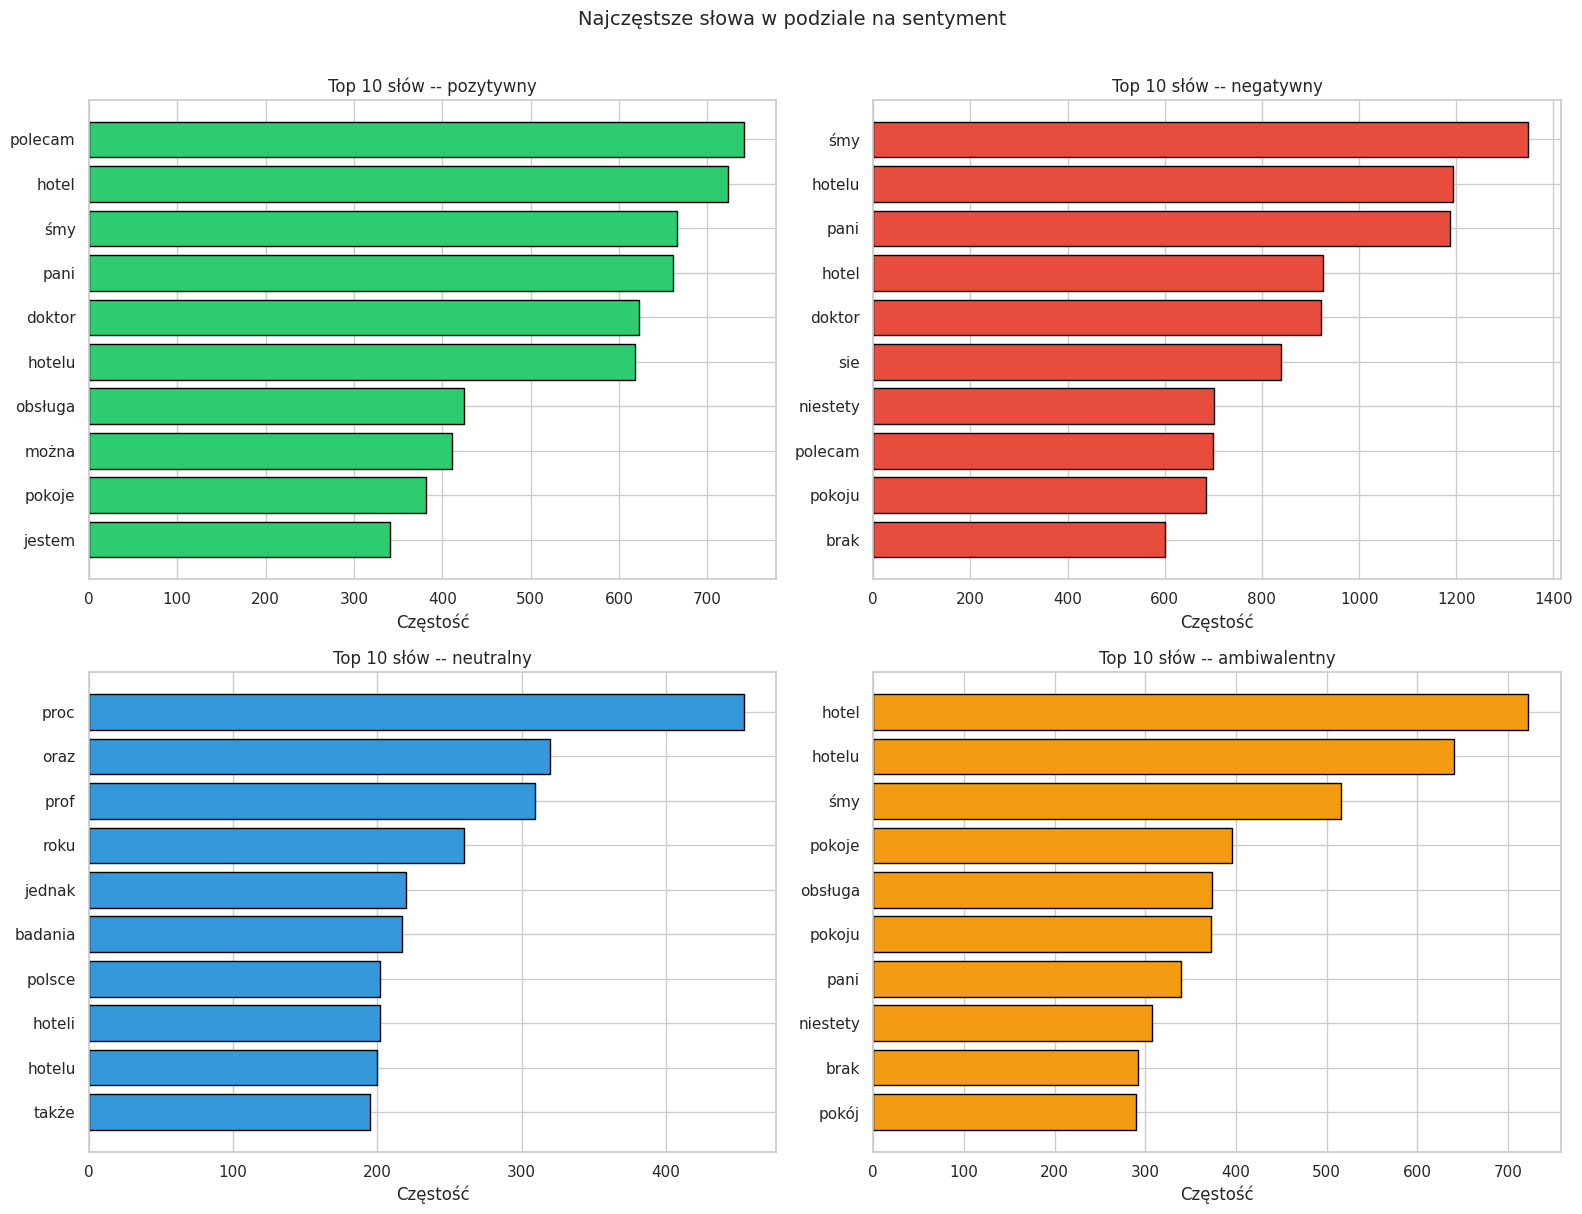

In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, (label, ax) in enumerate(zip(
    ["pozytywny", "negatywny", "neutralny", "ambiwalentny"],
    axes.flatten()
)):
    subset = df_train[df_train["label"] == label]
    words_subset = []
    for text in subset["sentence"]:
        tokens = tokenize_simple(text)
        filtered = [t for t in tokens if t not in polish_stopwords and len(t) > 2]
        words_subset.extend(filtered)

    top_10 = Counter(words_subset).most_common(10)
    if top_10:
        w, c = zip(*top_10)
        ax.barh(range(len(w)), c, color=colors[idx], edgecolor="black")
        ax.set_yticks(range(len(w)))
        ax.set_yticklabels(w)
        ax.invert_yaxis()
    ax.set_title(f"Top 10 słów -- {label}", fontsize=12)
    ax.set_xlabel("Częstość")

plt.suptitle("Najczęstsze słowa w podziale na sentyment", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Interpretacja

Porównanie najczęstszych słów między klasami może ujawnić, że np. w recenzjach pozytywnych dominują słowa oceniające ("polecam", "super"), a w negatywnych -- słowa wyrażające niezadowolenie. To cenna informacja przy budowaniu modeli klasyfikacji sentymentu.

---
---
## 2. Zadanie do samodzielnej realizacji -- A

### Analiza zbioru PolEmo2.0 Out-of-Domain

Załaduj wariant **Out-of-Domain** datasetu PolEmo2.0 (`allegro/klej-polemo2-out`) i wykonaj poniższe kroki.

**Wykonaj poniższe kroki:**

1. Załaduj dataset i przekonwertuj split treningowy na DataFrame.
2. Wyświetl **podstawowe statystyki**: liczbę przykładów, liczbę unikalnych etykiet, proporcje klas.
3. Porównaj rozkład klas między wariantem **In-Domain** a **Out-of-Domain** -- czy proporcje są podobne?
4. Oblicz średnią i medianę **długości recenzji** (w słowach) dla każdej klasy sentymentu.
5. Narysuj **histogram** porównujący rozkład długości tekstu między In-Domain a Out-of-Domain na jednym wykresie.
6. Znajdź **najdłuższą** i **najkrótszą** recenzję w zbiorze. Wyświetl ich treść i etykietę.

In [16]:
dataset_out = load_dataset("allegro/klej-polemo2-out")
df_out = dataset_out["train"].to_pandas()
display(df_out.head())

README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

valid.csv: 0.00B [00:00, ?B/s]

test.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/5783 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/494 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/494 [00:00<?, ? examples/s]

,sentence,target
0,Super lekarz i człowiek przez duże C . Bardzo ...,__label__meta_plus_m
1,Bardzo olewcze podejscie do pacjenta . Przypro...,__label__meta_minus_m
2,Lekarz zalecił mi kurację alternatywną do doty...,__label__meta_amb
3,""" Konsumenci oczywiście kierują się ceną . Te ...",__label__meta_zero
4,Pani Doktor Iwona jest profesjonalistką w każd...,__label__meta_plus_m


In [17]:
# Krok 2: Podstawowe statystyki
print(f"Liczba przykładów: {df_out.shape[0]}")
print(f"Liczba unikalnych etykiet: {df_out['target'].nunique()}")
print("\nProporcje klas:")
print(df_out["target"].value_counts(normalize=True).round(3))

Liczba przykładów: 5783
Liczba unikalnych etykiet: 4

Proporcje klas:
target
__label__meta_minus_m    0.379
__label__meta_plus_m     0.271
__label__meta_amb        0.182
__label__meta_zero       0.168
Name: proportion, dtype: float64


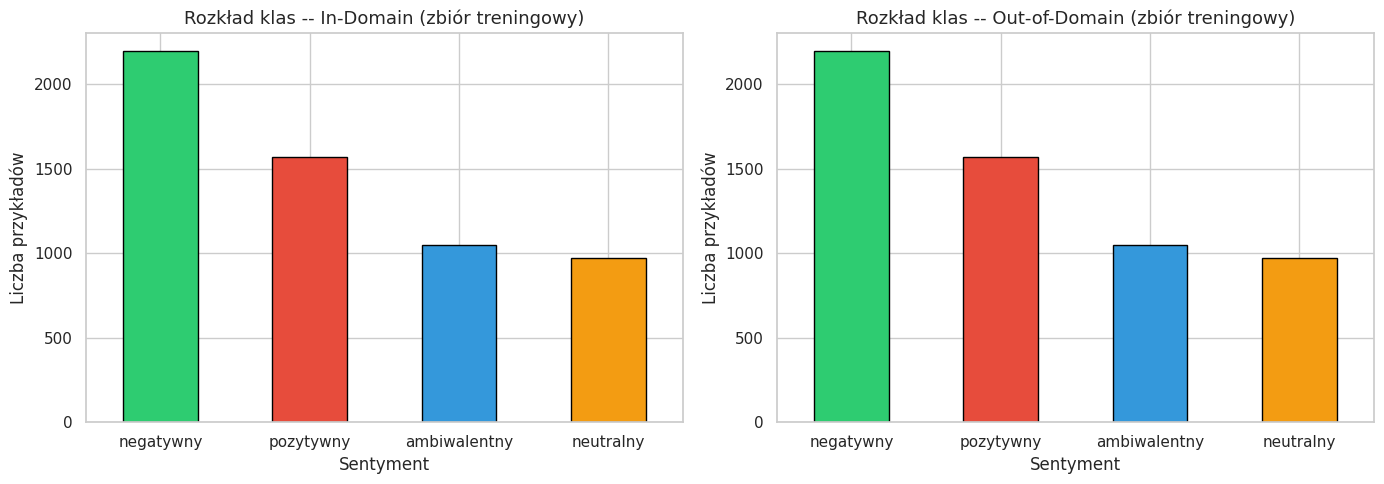

In [18]:
# Krok 3: Porównanie rozkładów klas In-Domain vs Out-of-Domain
# Wskazówka: narysuj dwa wykresy słupkowe obok siebie (subplots)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# In-Domain distribution (from df_train, already mapped labels)
df_train["label"].value_counts().plot(kind="bar", ax=axes[0], color=colors, edgecolor="black")
axes[0].set_title("Rozkład klas -- In-Domain (zbiór treningowy)", fontsize=13)
axes[0].set_xlabel("Sentyment")
axes[0].set_ylabel("Liczba przykładów")
axes[0].tick_params(axis="x", rotation=0)

# Out-of-Domain distribution (map labels first for consistency)
df_out["label"] = df_out["target"].map(label_map)
df_out["label"].value_counts().plot(kind="bar", ax=axes[1], color=colors, edgecolor="black")
axes[1].set_title("Rozkład klas -- Out-of-Domain (zbiór treningowy)", fontsize=13)
axes[1].set_xlabel("Sentyment")
axes[1].set_ylabel("Liczba przykładów")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

In [19]:
# Krok 4: Średnia i mediana długości w podziale na klasy
# Wskazówka: df_out.groupby("target")["num_words"].agg(["mean", "median"])

df_out["num_words"] = df_out["sentence"].str.split().str.len()
print("Średnia i mediana długości recenzji (w słowach) w podziale na sentyment (Out-of-Domain):")
print(df_out.groupby("label")["num_words"].agg(["mean", "median"]).round(1))

Średnia i mediana długości recenzji (w słowach) w podziale na sentyment (Out-of-Domain):
               mean  median
label                      
ambiwalentny  132.7   111.0
negatywny     150.5   125.0
neutralny     138.7   136.0
pozytywny     120.2   105.5


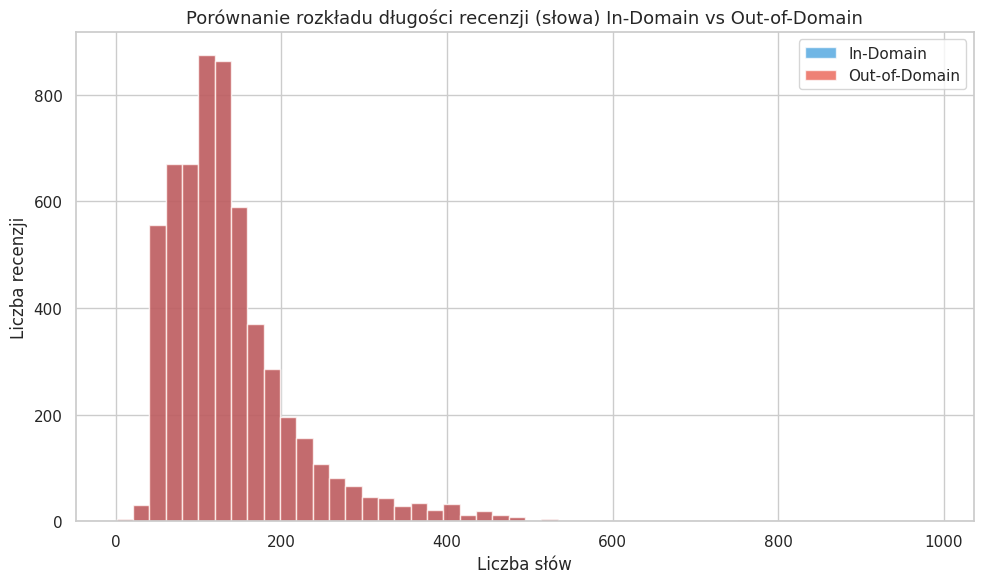

In [20]:
# Krok 5: Histogram porównawczy In-Domain vs Out-of-Domain
# Wskazówka: plt.hist([dane1, dane2], label=[...], alpha=0.7)

plt.figure(figsize=(10, 6))
plt.hist(df_train["num_words"], bins=50, alpha=0.7, label="In-Domain", color="#3498db")
plt.hist(df_out["num_words"], bins=50, alpha=0.7, label="Out-of-Domain", color="#e74c3c")
plt.title("Porównanie rozkładu długości recenzji (słowa) In-Domain vs Out-of-Domain", fontsize=13)
plt.xlabel("Liczba słów")
plt.ylabel("Liczba recenzji")
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# Krok 6: Najdłuższa i najkrótsza recenzja
# Wskazówka: idxmax(), idxmin() na kolumnie z liczbą słów

# Najdłuższa recenzja
longest_review_idx = df_out["num_words"].idxmax()
longest_review = df_out.loc[longest_review_idx]
print("Najdłuższa recenzja:")
print(f"  Liczba słów: {longest_review['num_words']}")
print(f"  Etykieta: {longest_review['label']}")
print(f"  Treść: {longest_review['sentence']}\n")

# Najkrótsza recenzja
shortest_review_idx = df_out["num_words"].idxmin()
shortest_review = df_out.loc[shortest_review_idx]
print("Najkrótsza recenzja:")
print(f"  Liczba słów: {shortest_review['num_words']}")
print(f"  Etykieta: {shortest_review['label']}")
print(f"  Treść: {shortest_review['sentence']}")

Najdłuższa recenzja:
  Liczba słów: 987
  Etykieta: negatywny
  Treść: Wybór sylwestrowego pakietu w tym hotelu za gigantyczne pieniądze ( jak na zaproponowane warunki i " atrakcje " ) to jeden z naszych największych błędów . Kierowali śmy się reklamami , ogłoszeniami i wizerunkiem hotelu , który kreuje się na mega luksusowy . . . Po 4 godzinach podróży z dzieckiem i kotem otrzymali śmy kartę do pokoju hotelowego . . . Kiedy do niego weszli śmy z wrażenia opadła m na łóżko , zaścielone pomiętą , wygniecioną pościelą . W pokoju . . . brud . Wykładzina poplamiona , w pokoju jedno okno , balkonowe , nieszczelne , problem z otwarciem ( jak wywietrzyć pokój , z jednym balkonowym oknem , którego nie można uchylić , kiedy przyjeżdża się z kotem ? ) na szybach skraplająca się woda , firanki pogniecione , pozaciągane , niedoprane . Stolik nocny z zepsutą szufladą . Abażury lampek mocno po przejściach , ściany obrzydliwie brudne , zaplamione , brak klimatyzacji . No i wisienka na torcie - łazien

---
---
## 3. Zadanie do samodzielnej realizacji -- B

### Analiza innego datasetu KLEJ -- Allegro Reviews

Załaduj dataset **Allegro Reviews** (`allegro/klej-ar`) -- zbiór recenzji produktów z serwisu Allegro z ocenami od 1 do 5.

**Wykonaj poniższe kroki:**

1. Załaduj dataset i wyświetl jego strukturę (`print(dataset)` i `.to_pandas().head()`).
2. Narysuj **rozkład ocen** (1-5) jako wykres słupkowy. Czy oceny są zbalansowane?
3. Oblicz **statystyki długości** tekstu (znaki i słowa) w podziale na ocenę (rating).
4. Narysuj **boxplot** długości tekstu w podziale na ocenę -- czy klienci piszą więcej przy skrajnych ocenach?
5. Znajdź **10 najczęstszych słów** dla recenzji z oceną 1 (negatywne) i z oceną 5 (pozytywne). Porównaj je.
6. Oblicz **macierz korelacji** między długością tekstu (słowa i znaki) a oceną. Narysuj ją jako heatmapę.

In [43]:
dataset_ar = load_dataset("allegro/klej-allegro-reviews")
df_ar = dataset_ar["train"].to_pandas()

print(type(dataset_ar))
print(dataset_ar)
display(df_ar.head())

<class 'datasets.dataset_dict.DatasetDict'>
DatasetDict({
    train: Dataset({
        features: ['text', 'rating'],
        num_rows: 9577
    })
    validation: Dataset({
        features: ['text', 'rating'],
        num_rows: 1002
    })
    test: Dataset({
        features: ['text', 'rating'],
        num_rows: 1006
    })
})


,text,rating
0,Jako do ceny dobra. Przyssawka mogłaby być lep...,3.0
1,Na słuchawkę czekałam spory czas a po zadzwoni...,1.0
2,"Czajnik na pierwszy rzut oka wygląda ok, ale n...",1.0
3,"Bardzo fajny czajnik, na pewno nie gorszy od m...",4.0
4,Pomysł na produkt (uchwyt na kierownicę) bardz...,2.0


In [40]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


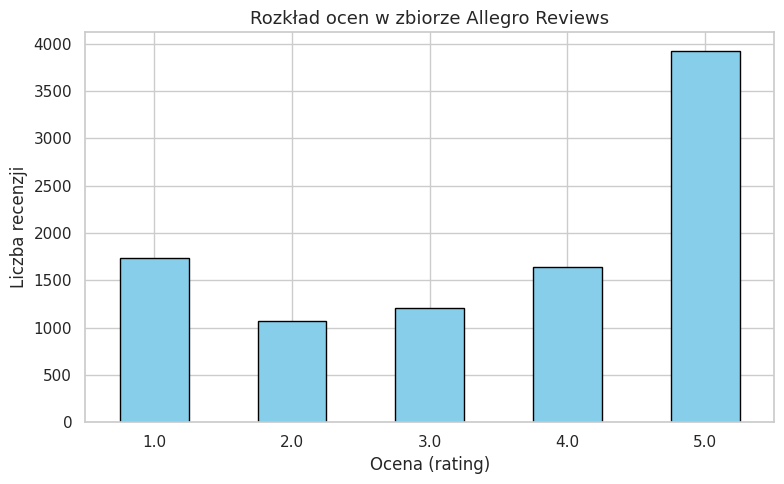

Rozkład ocen:
rating
1.0    1733
2.0    1069
3.0    1208
4.0    1644
5.0    3923
Name: count, dtype: int64


In [44]:
# Krok 2: Rozkład ocen (1-5)
# Wskazówka: df_ar["rating"].value_counts().sort_index().plot(kind="bar")

plt.figure(figsize=(8, 5))
df_ar["rating"].value_counts().sort_index().plot(kind="bar", color="skyblue", edgecolor="black")
plt.title("Rozkład ocen w zbiorze Allegro Reviews", fontsize=13)
plt.xlabel("Ocena (rating)")
plt.ylabel("Liczba recenzji")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Rozkład ocen:")
print(df_ar["rating"].value_counts().sort_index())

In [45]:
# Krok 3: Statystyki długości w podziale na ocenę
# Wskazówka: groupby("rating") + agg

df_ar["num_chars"] = df_ar["text"].str.len()
df_ar["num_words"] = df_ar["text"].str.split().str.len()

print("Statystyki długości (znaki) w podziale na ocenę:")
print(df_ar.groupby("rating")["num_chars"].agg(["mean", "median", "std", "min", "max"]).round(1))

print("\nStatystyki długości (słowa) w podziale na ocenę:")
print(df_ar.groupby("rating")["num_words"].agg(["mean", "median", "std", "min", "max"]).round(1))

Statystyki długości (znaki) w podziale na ocenę:
         mean  median    std  min   max
rating                                 
1.0     495.9   427.0  271.3   51  4995
2.0     491.2   429.0  194.1   61  1991
3.0     510.8   431.0  280.6   50  4229
4.0     495.5   426.5  250.0   50  3865
5.0     448.8   404.0  335.6   50  5000

Statystyki długości (słowa) w podziale na ocenę:
        mean  median   std  min   max
rating                               
1.0     76.9    66.0  41.7    0   752
2.0     75.8    66.0  29.6    0   300
3.0     78.8    67.0  41.8    0   605
4.0     75.8    66.0  38.2    0   567
5.0     66.5    61.0  56.3    0  1667


/tmp/ipykernel_5430/782297458.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ar, x="rating", y="num_words", palette="viridis")


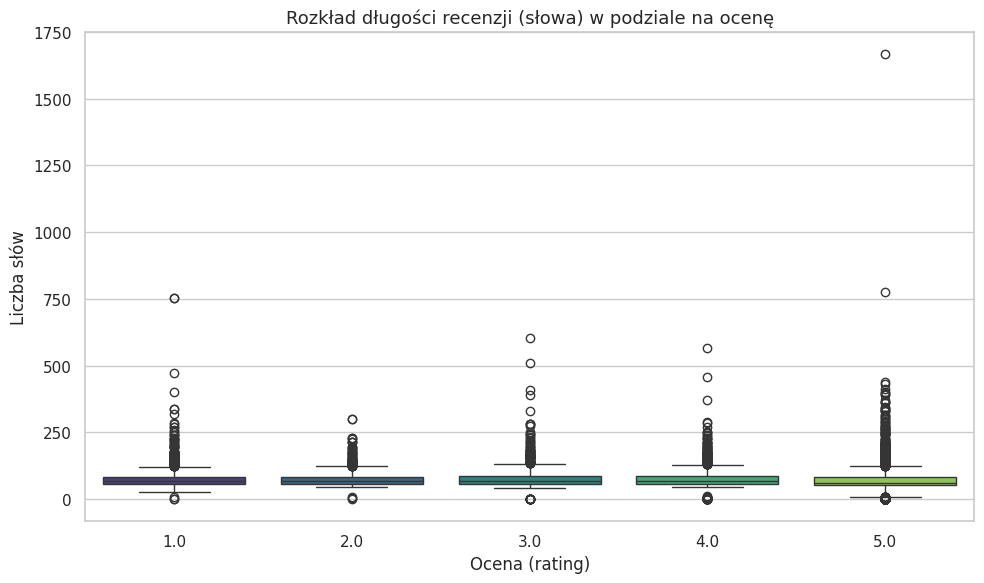

In [46]:
# Krok 4: Boxplot długości vs ocena
# Wskazówka: sns.boxplot(data=df_ar, x="rating", y="num_words")

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_ar, x="rating", y="num_words", palette="viridis")
plt.title("Rozkład długości recenzji (słowa) w podziale na ocenę", fontsize=13)
plt.xlabel("Ocena (rating)")
plt.ylabel("Liczba słów")
plt.tight_layout()
plt.show()

In [47]:
# Krok 5: Top 10 słów dla oceny 1 i oceny 5

def tokenize_simple(text):
    """Prosta tokenizacja: lowercase + usunięcie znaków specjalnych."""
    text = text.lower()
    tokens = re.findall(r'\b[a-ząćęłńóśźż]+\b', text)
    return tokens

polish_stopwords = {
    "i", "w", "na", "z", "do", "nie", "się", "to", "jest", "że",
    "o", "jak", "ale", "co", "tak", "za", "po", "od", "już", "a",
    "przez", "by", "tym", "ze", "tego", "ten", "ta", "te", "bardzo",
    "też", "tylko", "czy", "był", "była", "było", "być", "są",
    "ma", "ich", "dla", "mnie", "mi", "ja", "sobie", "go", "pan",
    "przy", "u", "no", "jeszcze", "tu", "tam", "kiedy", "gdy",
    "wszystko", "może", "więc", "który", "która", "które", "których",
    "którzy", "mam", "będzie", "moim", "mojej", "mój", "moja",
    "bo", "ni", "lub"
}

# Słowa dla oceny 1 (negatywne)
words_rating_1 = []
for text in df_ar[df_ar["rating"] == 1.0]["text"]:
    tokens = tokenize_simple(text)
    filtered = [t for t in tokens if t not in polish_stopwords and len(t) > 2]
    words_rating_1.extend(filtered)

top_10_rating_1 = Counter(words_rating_1).most_common(10)

print("10 najczęstszych słów dla ocen 1.0 (negatywne):")
for word, count in top_10_rating_1:
    print(f"  {word:20s} {count}")

print("\n" + "-"*50 + "\n")

# Słowa dla oceny 5 (pozytywne)
words_rating_5 = []
for text in df_ar[df_ar["rating"] == 5.0]["text"]:
    tokens = tokenize_simple(text)
    filtered = [t for t in tokens if t not in polish_stopwords and len(t) > 2]
    words_rating_5.extend(filtered)

top_10_rating_5 = Counter(words_rating_5).most_common(10)

print("10 najczęstszych słów dla ocen 5.0 (pozytywne):")
for word, count in top_10_rating_5:
    print(f"  {word:20s} {count}")

10 najczęstszych słów dla ocen 1.0 (negatywne):
  polecam              599
  szkło                589
  etui                 491
  produkt              393
  telefon              392
  nawet                369
  telefonu             363
  niestety             356
  działa               316
  bez                  290

--------------------------------------------------

10 najczęstszych słów dla ocen 5.0 (pozytywne):
  polecam              1454
  dobrze               919
  bez                  853
  można                847
  super                755
  działa               677
  etui                 635
  telefon              598
  trzeba               597
  jakość               593


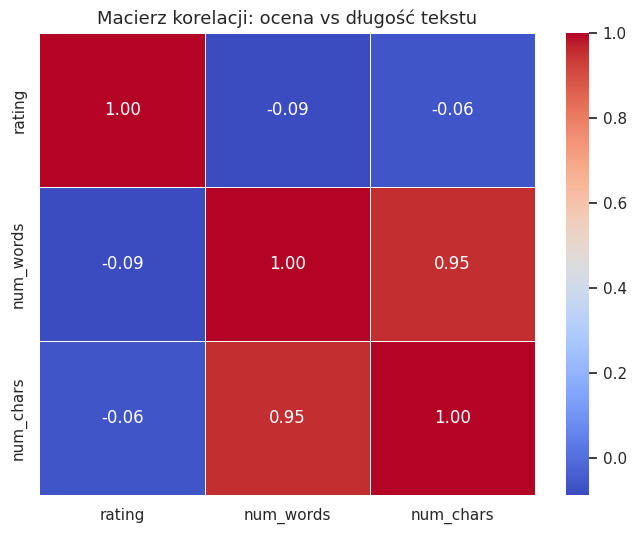

Macierz korelacji:
             rating  num_words  num_chars
rating     1.000000  -0.086907  -0.064152
num_words -0.086907   1.000000   0.953965
num_chars -0.064152   0.953965   1.000000


In [48]:
# Krok 6: Macierz korelacji i heatmapa
# Wskazówka: df_ar[["rating", "num_words", "num_chars"]].corr()
# sns.heatmap(corr, annot=True, cmap="coolwarm")

corr_matrix = df_ar[["rating", "num_words", "num_chars"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Macierz korelacji: ocena vs długość tekstu", fontsize=13)
plt.show()

print("Macierz korelacji:")
print(corr_matrix)